[2026-08-02 17:18:43] [info     ] 计算优化合成因子，区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
优化合成因子每日原始覆盖率：
count    242.000000
mean       0.719074
std        0.092830
min        0.375000
25%        0.662500
50%        0.713000
75%        0.788500
max        0.916000
Name: factor, dtype: float64
原始覆盖率最低的 10 个交易日：
date
2024-02-05    0.375
2024-02-02    0.472
2024-02-06    0.485
2024-01-31    0.488
2024-02-01    0.498
2024-01-30    0.519
2024-02-07    0.528
2024-01-22    0.545
2024-01-23    0.547
2024-02-08    0.553
Name: factor, dtype: float64
[2026-08-02 17:19:48] [info     ] 读取因子库，区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-08-02 17:19:48] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-08-02 17:19:51] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-08-02 17:19:52] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-08-02 17:19:52] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-01-02 至 2024-12-31
[2026-08-02 17:19:52] [info     ] =

时段,IC
2024-01-15~2024-02-08,0.0195
2024-09-24~2024-10-08,0.0458

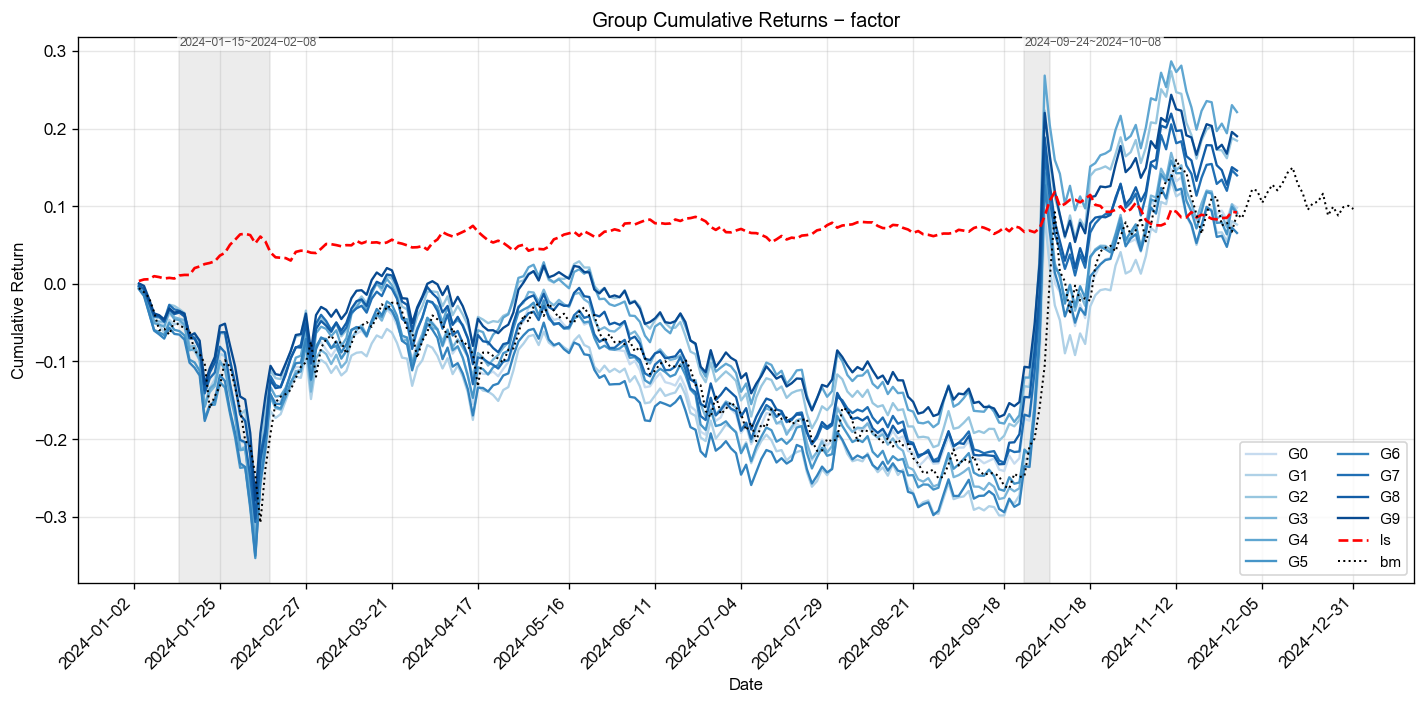
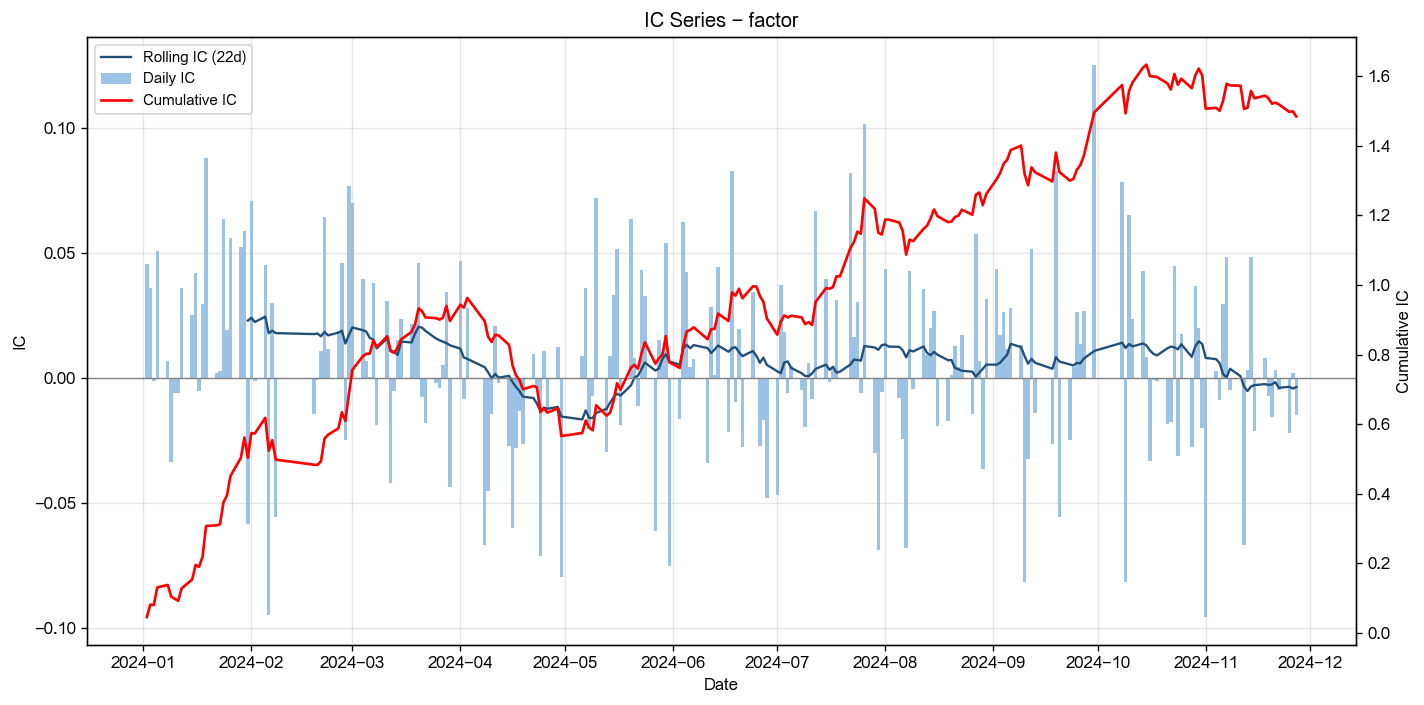
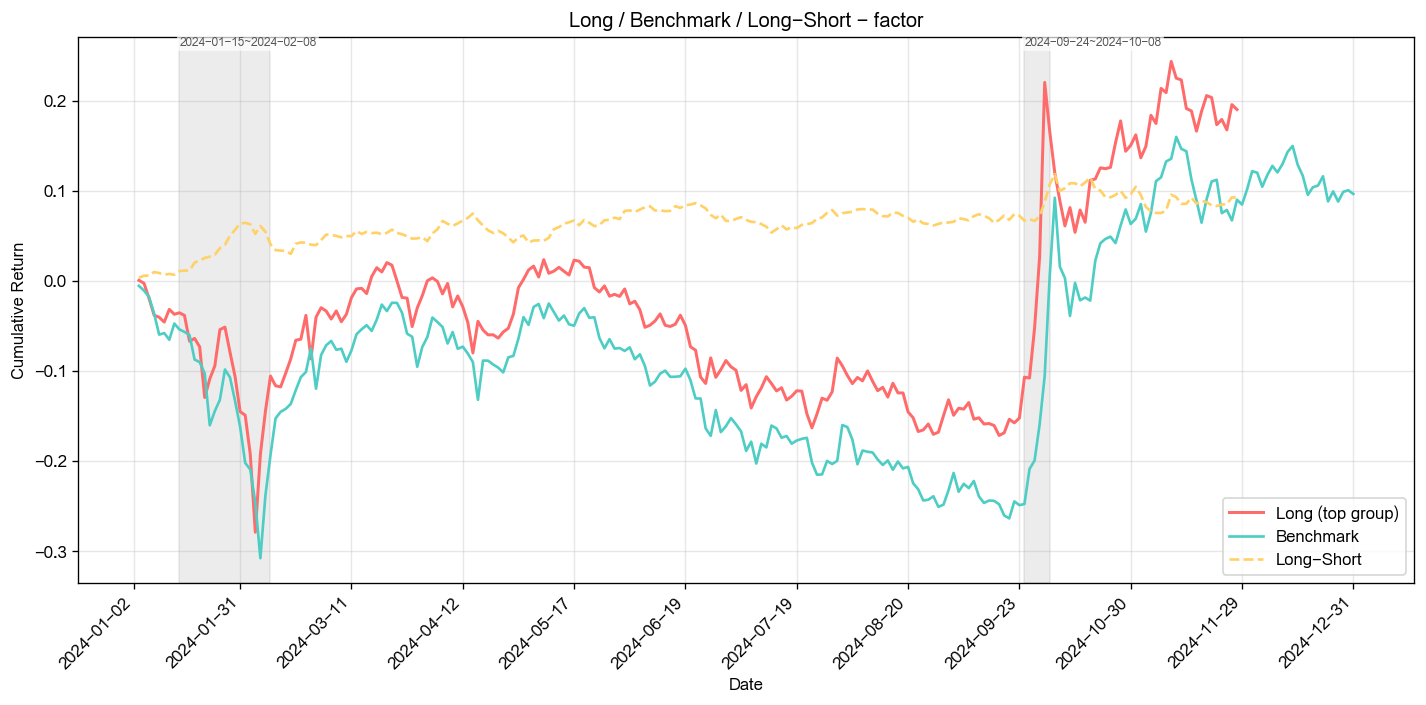
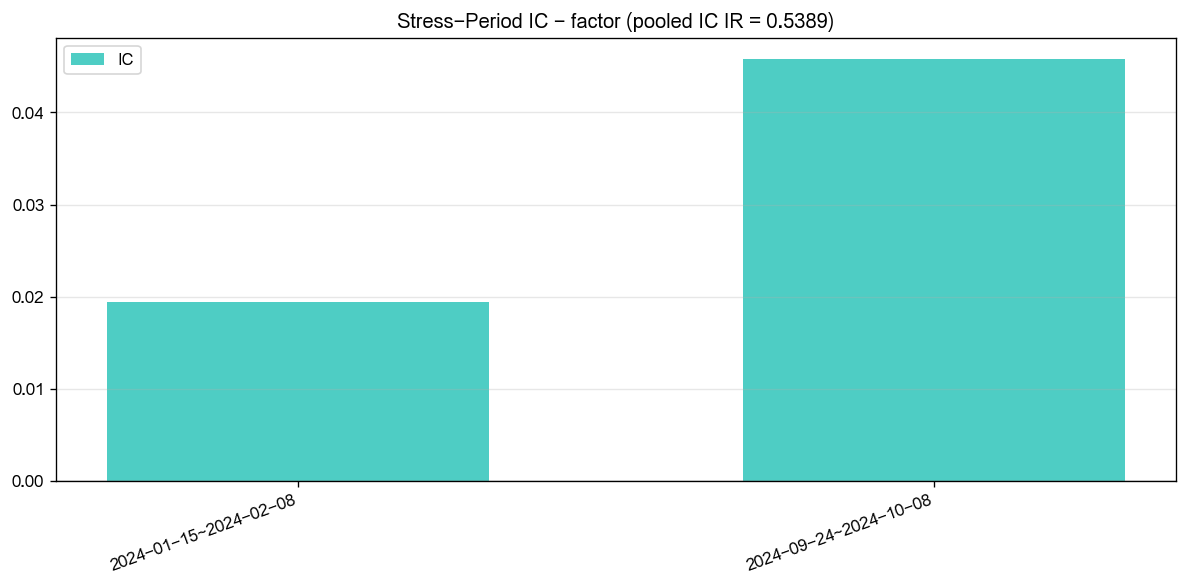
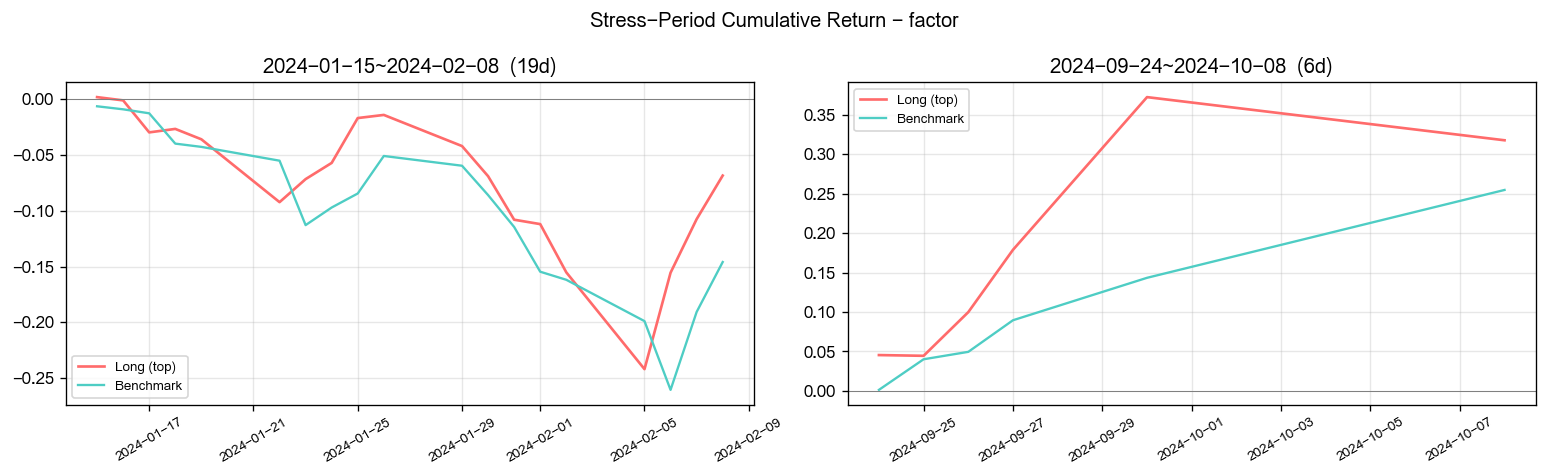

[2026-08-02 17:20:05] [info     ] ========== 因子池回归 ==========
[2026-08-02 17:20:06] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-08-02 17:20:06] [info     ] 获取收益率数据, 耗时: 0.7777 秒
[2026-08-02 17:20:07] [info     ] 滚动 Elastic Net 拟合, 耗时: 0.7166 秒
[2026-08-02 17:20:07] [info     ] 统计 回归结果, 耗时: 0.0945 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,rsi_12,1.9448,0.0448,0.0231,1.0000
2,amount,1.7167,0.0185,0.0108,0.9000
3,netflow_amount_rate_main,1.5971,0.0103,0.0064,1.0000
4,netflow_amount_main,1.5063,0.0246,0.0163,1.0000
5,gross_profit_rate_ttm,1.5047,0.0069,0.0046,1.0000
6,net_profit_rate_ttm,1.4420,0.0040,0.0028,0.8000
7,pb,1.4214,0.0097,0.0068,1.0000
8,bias_20,1.4021,0.0291,0.0207,0.9000
9,cci_14,1.3816,0.0338,0.0245,1.0000
10,pe_ttm,1.2999,0.0029,0.0022,0.9000

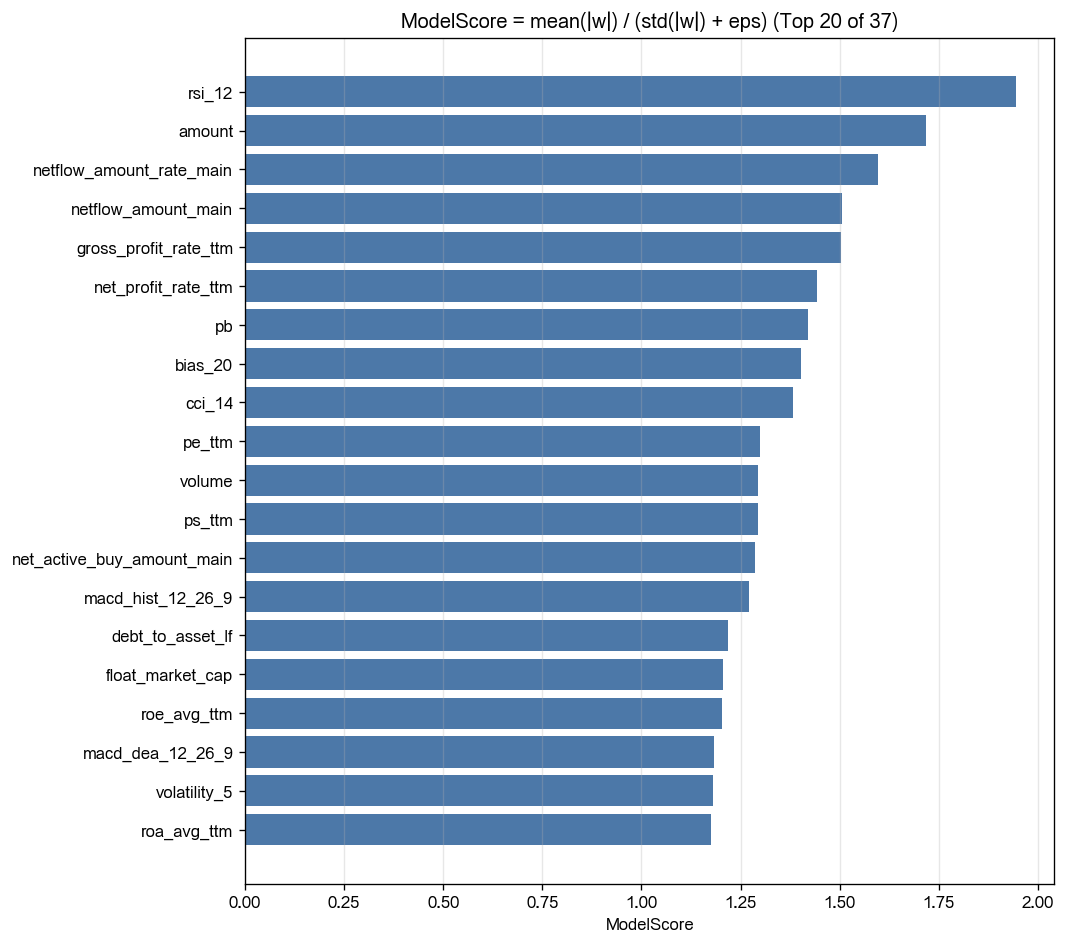
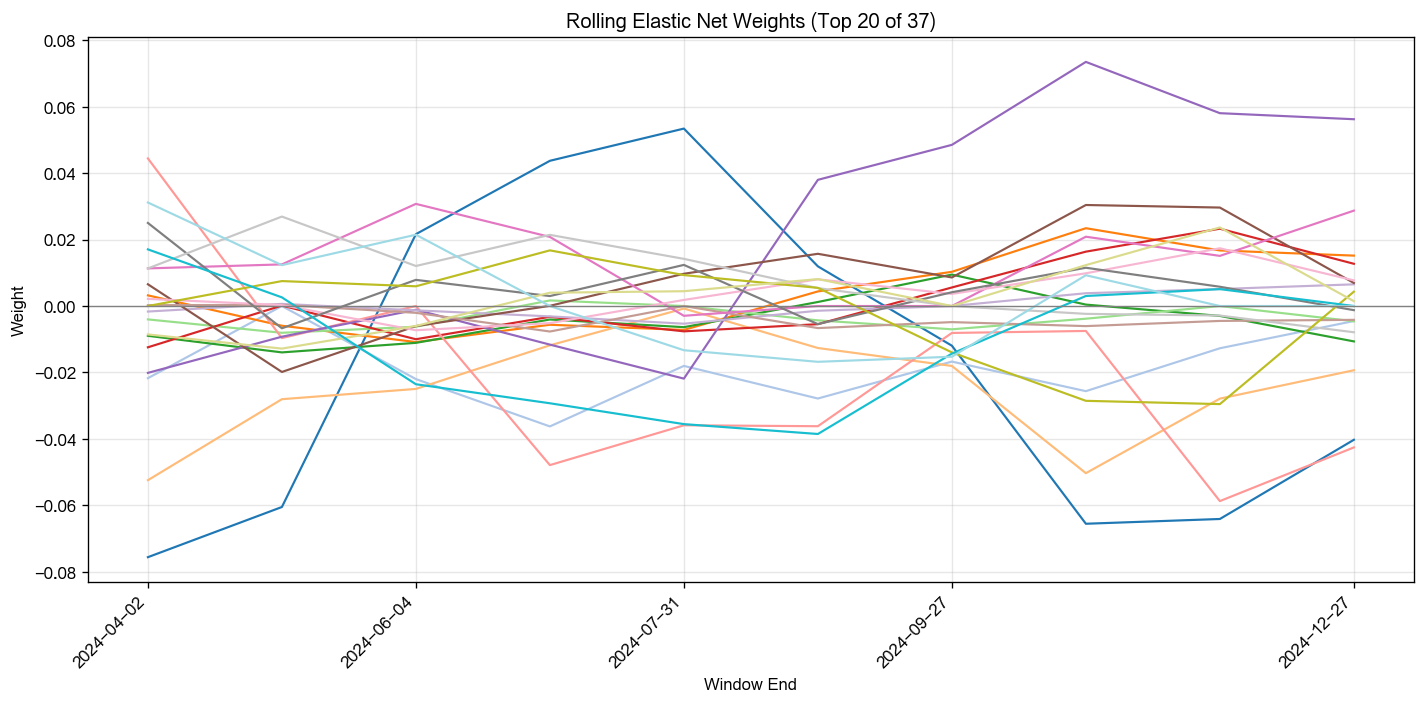
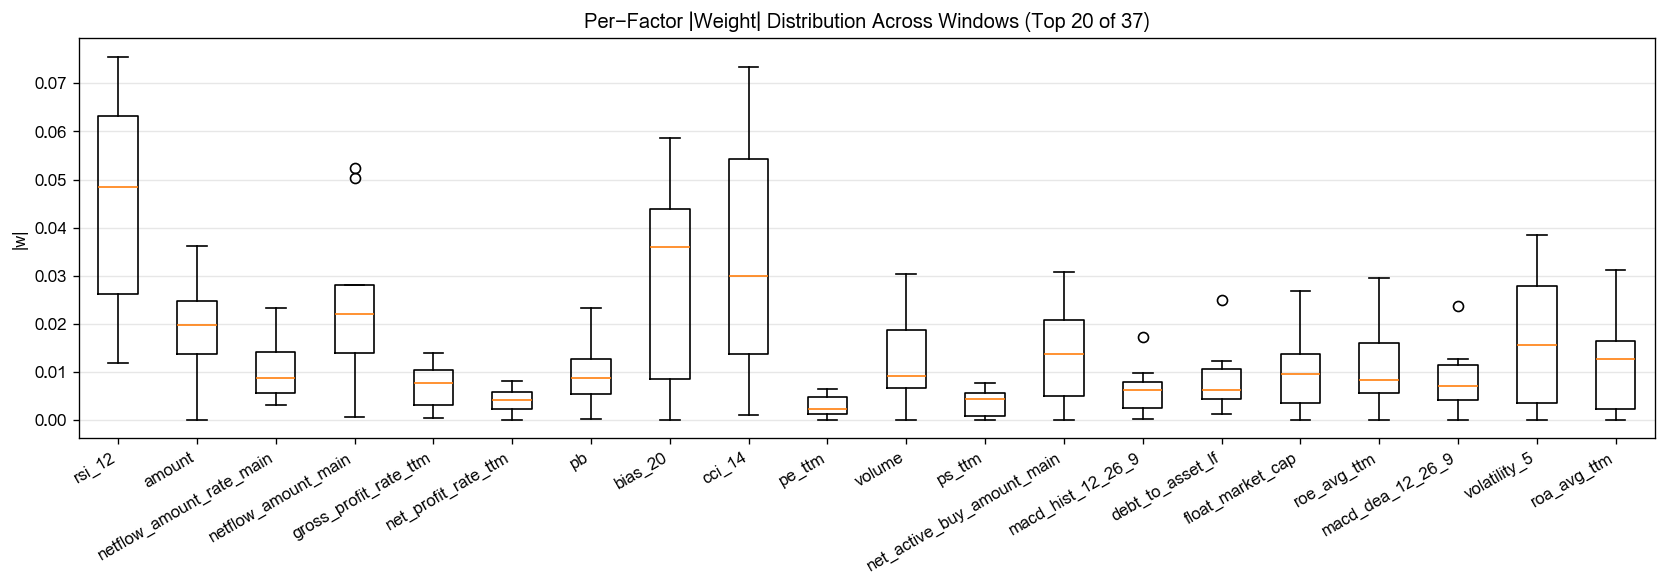
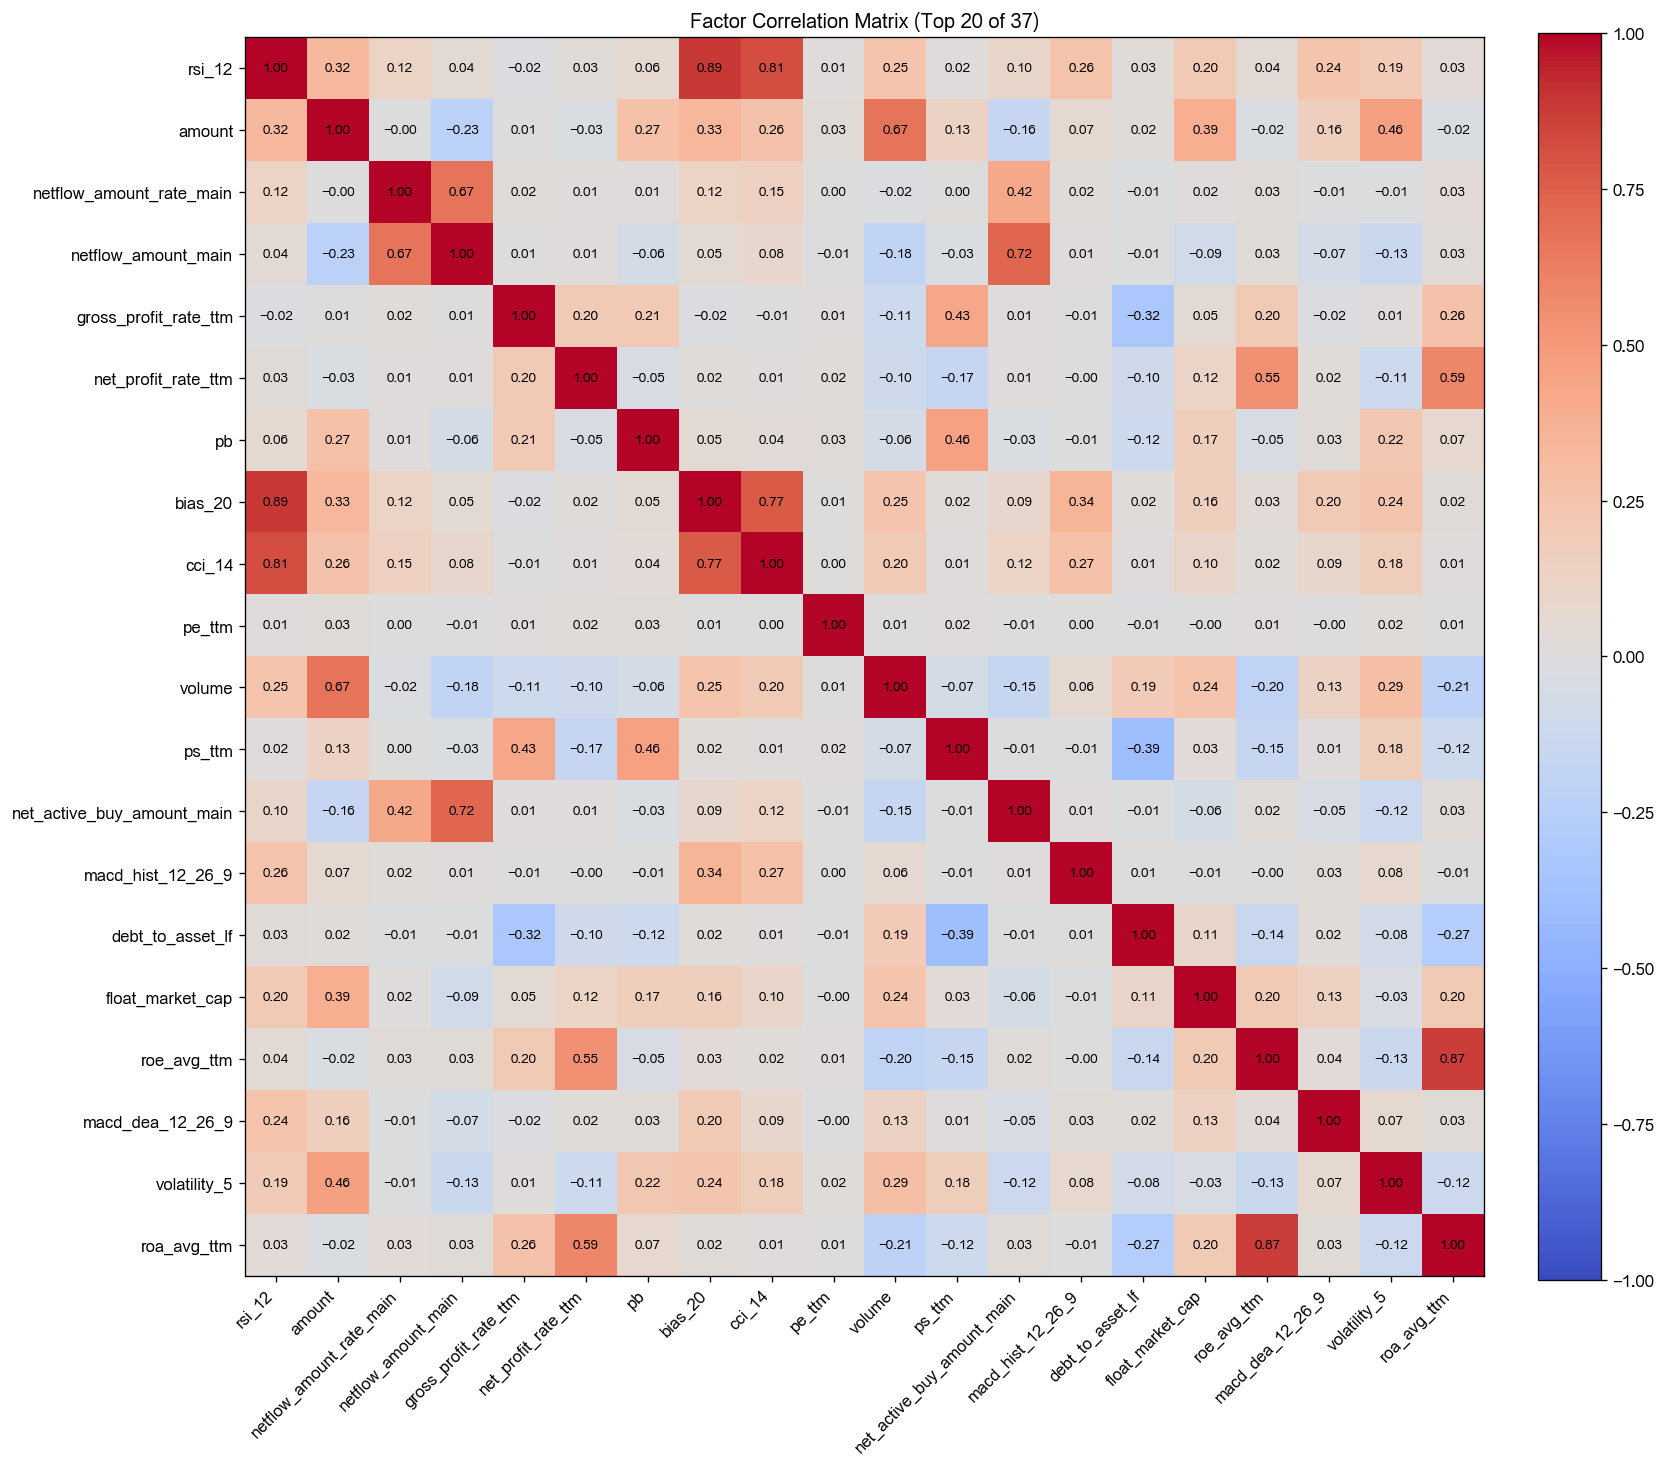

[2026-08-02 17:20:10] [warning  ] 返回的Outputs实例(size=35326081) 大于 64K, 将不会被缓存
[2026-08-02 17:20:10] [info     ] bigalpha_eval.v4 运行完成 [18.668s].


In [1]:
def main(datasources, start_date, end_date):
    """
    优化后的方向性订单簿合成因子。

    核心结构：
    1. 使用 50 万元盘口冲击构造经过验证的核心方向信号；
    2. 使用 10/30/100 万元构造覆盖率更高的深层形状斜率；
    3. 在每日横截面内分别标准化两个组件后再合成；
    4. 最终方向整体取反，以匹配下一交易日的实证反转方向；
    5. 使用“尾部确认”而非全截面线性混合：只有斜率与核心方向
       同号时，斜率才增强信号；冲突时保持纯核心方向；
    6. 暂不加入凸性和盘口韧性，避免低覆盖、低样本组件稀释信号。

    返回列严格为：date, instrument, factor。
    """
    import re

    import numpy as np
    import pandas as pd
    import dai

    bar1m = datasources["bar1m"]

    # 表名来自平台注入，但仍做一次标识符校验。
    if not re.fullmatch(r"[A-Za-z_][A-Za-z0-9_.]*", bar1m):
        raise ValueError(f"非法的 bar1m 数据表名: {bar1m}")

    eps = 1e-12

    # 尾部确认强度。建议只在 0.20/0.30/0.40 三档中做稳健性比较。
    # 0.30 是兼顾多空区分度与核心 IC 稳定性的初始值。
    confirm_weight = 0.30

    sql = f"""
    WITH raw_depth AS (
        SELECT
            date AS snapshot_time,
            CAST(date AS DATE) AS trade_date,
            instrument,

            (ask_price1 + bid_price1) / 2.0 AS midprice,

            ask_price1,
            ask_price2,
            ask_price3,
            ask_price4,
            ask_price5,

            bid_price1,
            bid_price2,
            bid_price3,
            bid_price4,
            bid_price5,

            ask_volume1,
            ask_volume2,
            ask_volume3,
            ask_volume4,
            ask_volume5,

            bid_volume1,
            bid_volume2,
            bid_volume3,
            bid_volume4,
            bid_volume5

        FROM {bar1m}

        WHERE ask_price1 > 0
          AND bid_price1 > 0
          AND ask_price1 >= bid_price1
          AND ask_volume1 >= 0
          AND ask_volume2 >= 0
          AND ask_volume3 >= 0
          AND ask_volume4 >= 0
          AND ask_volume5 >= 0
          AND bid_volume1 >= 0
          AND bid_volume2 >= 0
          AND bid_volume3 >= 0
          AND bid_volume4 >= 0
          AND bid_volume5 >= 0
    ),

    /*
    四个金额各有不同用途：
      10/30/100 万元：用于订单簿形状；
      50 万元：保留此前已经检验的核心方向信号。
    */
    depth_by_q AS (
        SELECT
            d.*,
            q.q_value,
            q.q_value / NULLIF(d.midprice, 0) AS target_qty

        FROM raw_depth d

        CROSS JOIN (
            VALUES
                (100000.0),
                (300000.0),
                (500000.0),
                (1000000.0)
        ) AS q(q_value)

        WHERE d.midprice > 0
    ),

    /*
    按目标数量逐档消耗五档盘口。最后一档只取实际需要的部分，
    避免把整档挂单错误纳入执行均价。
    */
    executed AS (
        SELECT
            *,

            LEAST(ask_volume1, target_qty) AS ask_fill1,

            LEAST(
                ask_volume2,
                GREATEST(target_qty - ask_volume1, 0)
            ) AS ask_fill2,

            LEAST(
                ask_volume3,
                GREATEST(
                    target_qty - ask_volume1 - ask_volume2,
                    0
                )
            ) AS ask_fill3,

            LEAST(
                ask_volume4,
                GREATEST(
                    target_qty
                    - ask_volume1
                    - ask_volume2
                    - ask_volume3,
                    0
                )
            ) AS ask_fill4,

            LEAST(
                ask_volume5,
                GREATEST(
                    target_qty
                    - ask_volume1
                    - ask_volume2
                    - ask_volume3
                    - ask_volume4,
                    0
                )
            ) AS ask_fill5,

            LEAST(bid_volume1, target_qty) AS bid_fill1,

            LEAST(
                bid_volume2,
                GREATEST(target_qty - bid_volume1, 0)
            ) AS bid_fill2,

            LEAST(
                bid_volume3,
                GREATEST(
                    target_qty - bid_volume1 - bid_volume2,
                    0
                )
            ) AS bid_fill3,

            LEAST(
                bid_volume4,
                GREATEST(
                    target_qty
                    - bid_volume1
                    - bid_volume2
                    - bid_volume3,
                    0
                )
            ) AS bid_fill4,

            LEAST(
                bid_volume5,
                GREATEST(
                    target_qty
                    - bid_volume1
                    - bid_volume2
                    - bid_volume3
                    - bid_volume4,
                    0
                )
            ) AS bid_fill5

        FROM depth_by_q
    ),

    execution_price AS (
        SELECT
            snapshot_time,
            trade_date,
            instrument,
            q_value,
            midprice,
            target_qty,

            ask_fill1
                + ask_fill2
                + ask_fill3
                + ask_fill4
                + ask_fill5 AS ask_filled_qty,

            bid_fill1
                + bid_fill2
                + bid_fill3
                + bid_fill4
                + bid_fill5 AS bid_filled_qty,

            (
                ask_price1 * ask_fill1
                + ask_price2 * ask_fill2
                + ask_price3 * ask_fill3
                + ask_price4 * ask_fill4
                + ask_price5 * ask_fill5
            ) / NULLIF(
                ask_fill1
                + ask_fill2
                + ask_fill3
                + ask_fill4
                + ask_fill5,
                0
            ) AS ask_exec_price,

            (
                bid_price1 * bid_fill1
                + bid_price2 * bid_fill2
                + bid_price3 * bid_fill3
                + bid_price4 * bid_fill4
                + bid_price5 * bid_fill5
            ) / NULLIF(
                bid_fill1
                + bid_fill2
                + bid_fill3
                + bid_fill4
                + bid_fill5,
                0
            ) AS bid_exec_price

        FROM executed
    ),

    impact_long AS (
        SELECT
            snapshot_time,
            trade_date,
            instrument,
            q_value,

            CASE
                WHEN ask_filled_qty >= target_qty * 0.999
                 AND bid_filled_qty >= target_qty * 0.999
                 AND ask_exec_price >= midprice
                 AND bid_exec_price <= midprice
                THEN
                    (ask_exec_price - midprice)
                    / NULLIF(midprice, 0)
                ELSE NULL
            END AS buy_cost,

            CASE
                WHEN ask_filled_qty >= target_qty * 0.999
                 AND bid_filled_qty >= target_qty * 0.999
                 AND ask_exec_price >= midprice
                 AND bid_exec_price <= midprice
                THEN
                    (midprice - bid_exec_price)
                    / NULLIF(midprice, 0)
                ELSE NULL
            END AS sell_cost

        FROM execution_price
    ),

    impact_wide AS (
        SELECT
            snapshot_time,
            trade_date,
            instrument,

            MAX(
                CASE WHEN q_value = 100000.0
                     THEN buy_cost END
            ) AS buy_small,

            MAX(
                CASE WHEN q_value = 100000.0
                     THEN sell_cost END
            ) AS sell_small,

            MAX(
                CASE WHEN q_value = 300000.0
                     THEN buy_cost END
            ) AS buy_middle,

            MAX(
                CASE WHEN q_value = 300000.0
                     THEN sell_cost END
            ) AS sell_middle,

            MAX(
                CASE WHEN q_value = 500000.0
                     THEN buy_cost END
            ) AS buy_core,

            MAX(
                CASE WHEN q_value = 500000.0
                     THEN sell_cost END
            ) AS sell_core,

            MAX(
                CASE WHEN q_value = 1000000.0
                     THEN buy_cost END
            ) AS buy_large,

            MAX(
                CASE WHEN q_value = 1000000.0
                     THEN sell_cost END
            ) AS sell_large

        FROM impact_long

        GROUP BY
            snapshot_time,
            trade_date,
            instrument
    ),

    minute_base AS (
        SELECT
            *,

            buy_small + sell_small AS width_small,
            buy_core + sell_core AS width_core,

            /* 50 万元核心方向。 */
            (buy_core - sell_core)
            / NULLIF(
                buy_core + sell_core + {eps},
                0
            ) AS direction_core,

            /* 10 万到 100 万的单位金额冲击斜率，金额单位为百万元。 */
            (buy_large - buy_small) / 0.9 AS slope_buy,
            (sell_large - sell_small) / 0.9 AS slope_sell

        FROM impact_wide
    ),

    minute_features AS (
        SELECT
            *,

            (slope_buy - slope_sell)
            / NULLIF(
                ABS(slope_buy)
                + ABS(slope_sell)
                + {eps},
                0
            ) AS slope_imbalance

        FROM minute_base
    ),

    daily_components AS (
        SELECT
            trade_date,
            instrument,

            AVG(direction_core) AS daily_direction_core,
            AVG(slope_imbalance) AS daily_slope_imbalance,
            AVG(width_small) AS daily_width_small,

            COUNT(direction_core) AS valid_core_count,
            COUNT(slope_imbalance) AS valid_slope_count,
            COUNT(width_small) AS valid_small_count

        FROM minute_features

        GROUP BY
            trade_date,
            instrument
    ),

    /*
    合成前按日做横截面标准化。平台后续仍会统一预处理；这里的目的
    是防止方向与斜率虽然都“有界”，实际波动尺度却相差很大。
    */
    daily_standardized AS (
        SELECT
            *,

            (
                daily_direction_core
                - AVG(daily_direction_core) OVER (
                    PARTITION BY trade_date
                )
            )
            / NULLIF(
                STDDEV_POP(daily_direction_core) OVER (
                    PARTITION BY trade_date
                ),
                0
            ) AS z_direction_raw,

            CASE
                WHEN daily_slope_imbalance IS NOT NULL
                THEN
                    (
                        daily_slope_imbalance
                        - AVG(daily_slope_imbalance) OVER (
                            PARTITION BY trade_date
                        )
                    )
                    / NULLIF(
                        STDDEV_POP(daily_slope_imbalance) OVER (
                            PARTITION BY trade_date
                        ),
                        0
                    )
                ELSE NULL
            END AS z_slope_raw,

            (
                daily_width_small
                - AVG(daily_width_small) OVER (
                    PARTITION BY trade_date
                )
            )
            / NULLIF(
                STDDEV_POP(daily_width_small) OVER (
                    PARTITION BY trade_date
                ),
                0
            ) AS z_width_raw

        FROM daily_components

        /* 核心方向至少需要 30 个有效分钟。 */
        WHERE valid_core_count >= 30
    ),

    daily_clipped AS (
        SELECT
            *,

            CASE
                WHEN z_direction_raw IS NOT NULL
                THEN GREATEST(-3.0, LEAST(3.0, z_direction_raw))
                ELSE NULL
            END AS z_direction,

            CASE
                WHEN z_slope_raw IS NOT NULL
                THEN GREATEST(-3.0, LEAST(3.0, z_slope_raw))
                ELSE NULL
            END AS z_slope,

            CASE
                WHEN z_width_raw IS NOT NULL
                THEN GREATEST(-3.0, LEAST(3.0, z_width_raw))
                ELSE NULL
            END AS z_width

        FROM daily_standardized
    )

    , combined_signal AS (
        SELECT
            *,

            /*
            核心方向和斜率在此前检验中都呈次日反转，因此均取负号。

            斜率只在与核心信号同号时增强尾部：
              z_direction * z_slope > 0
            等价于：
              (-z_direction) 与 (-z_slope) 同号。

            如果两者冲突或斜率缺失，退化为纯核心方向，不让低覆盖
            的形状变量推翻已经验证的核心排序。
            */
            -z_direction
            + CASE
                WHEN z_slope IS NOT NULL
                 AND z_direction * z_slope > 0
                THEN {confirm_weight} * (-z_slope)
                ELSE 0.0
              END AS factor_raw

        FROM daily_clipped

        WHERE z_direction IS NOT NULL
    ),

    /*
    对非线性合成结果再次做每日横截面标准化。该步骤不改变当日排序，
    但可让不同时期的因子尺度保持一致，减少滚动回归权重波动。
    */
    combined_standardized AS (
        SELECT
            *,

            (
                factor_raw
                - AVG(factor_raw) OVER (
                    PARTITION BY trade_date
                )
            )
            / NULLIF(
                STDDEV_POP(factor_raw) OVER (
                    PARTITION BY trade_date
                ),
                0
            ) AS factor_z

        FROM combined_signal
    )

    SELECT
        trade_date,
        instrument,

        CASE
            WHEN factor_z IS NOT NULL
            THEN GREATEST(-3.0, LEAST(3.0, factor_z))
            ELSE NULL
        END AS factor,

        valid_core_count,
        valid_slope_count,
        valid_small_count,
        z_direction,
        z_slope,
        z_width

    FROM combined_standardized

    ORDER BY trade_date, instrument
    """

    df = dai.query(
        sql,
        filters={"date": [start_date, end_date]},
        compression=True,
    ).df()

    df = df.rename(columns={"trade_date": "date"})
    df["date"] = pd.to_datetime(df["date"])

    # 对齐历史时点上的中证 1000 成分股。
    stk_pool = dai.query(
        """
        SELECT date, instrument
        FROM bigalpha_2026_instruments
        """,
        filters={"date": [start_date, end_date]},
    ).df()

    stk_pool["date"] = pd.to_datetime(stk_pool["date"])

    df = pd.merge(
        stk_pool,
        df,
        how="left",
        on=["date", "instrument"],
    )

    df["factor"] = df["factor"].replace(
        [np.inf, -np.inf],
        np.nan,
    )

    # 诊断必须在缺失值填补之前完成。
    coverage = (
        df.groupby("date")["factor"]
        .apply(lambda x: x.notna().mean())
    )

    print("优化合成因子每日原始覆盖率：")
    print(coverage.describe())
    print("原始覆盖率最低的 10 个交易日：")
    print(coverage.nsmallest(10))

    # 中位数代表当日没有额外方向证据，保证提交满足覆盖率要求。
    daily_median = df.groupby("date")["factor"].transform("median")
    df["factor"] = df["factor"].fillna(daily_median)
    df["factor"] = df["factor"].fillna(0.0)

    return df[["date", "instrument", "factor"]]


if __name__ == "__main__":
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()

    datasources = {
        "bar1m": "bigalpha_2026_stock_bar1m",
    }
    start_date = "2024-01-01 00:00:00"
    end_date = "2024-12-31 23:59:59"

    logger.info(
        f"计算优化合成因子，区间：{start_date} ~ {end_date}"
    )
    factor_data = main(datasources, start_date, end_date)

    logger.info(
        f"读取因子库，区间：{start_date} ~ {end_date}"
    )
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={"date": [start_date, end_date]},
    ).df()

    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )
